# Credit Card Fraud Detection: Modeling Pipeline

**Project:** ML Fraud Detection Pipeline · **Author:** Felipe Toro · **Notebook:** 02 of 03

---

## Purpose

Train, tune, evaluate, and select the production model. Notebook 01 established the data and the cost framing. This notebook executes on those findings.

## Decisions inherited from Notebook 01

- Class imbalance 1:545 → stratified splits, AUC-PR as the CV scoring metric
- Cost asymmetry 25:1 (FN $125 vs FP $5) → threshold selection optimizes expected dollar cost, not F1
- Non-linear feature separation → tree-based ensembles in the candidate set
- 61 missing cells → median imputation inside the sklearn Pipeline

## What this notebook produces

1. Six tuned candidate models (Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost, MLP)
2. A model comparison table ranked by expected dollar cost
3. SHAP attribution against the winning model
4. A cost-optimized classification threshold
5. The serialized production artifact at `models/xgboost_best.pkl`

The artifact in step 5 is the deployable output, the file that Session 3's FastAPI service loads at startup.

---
## 1. Setup

Imports, path resolution, and the centralized data loader. Path detection anchors on `README.md` so the notebook executes correctly from any working directory.

In [18]:
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import joblib

# Project root anchors on README.md so the notebook is portable across
# launch contexts (notebook server, VS Code, CI). Path manipulation at
# this layer rather than at every call site eliminates a class of bugs.
_cwd = Path.cwd()
if (_cwd / "README.md").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "README.md").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd

sys.path.insert(0, str(PROJECT_ROOT))

# Output locations referenced by the README and by Session 3's API service.
# Created idempotently so re-runs do not fail.
IMAGES_DIR = PROJECT_ROOT / "docs" / "images"
MODELS_DIR = PROJECT_ROOT / "models"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Scientific stack and ML libraries.
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna
import mlflow
import mlflow.sklearn
import shap

# Project utilities. single source of truth for schema, evaluation, and
# cost framing. Imports here would fail loudly if the project layout were
# broken, surfacing structural issues immediately.
from src.data.loader import (
    load_training_data, split_features_target,
    PCA_FEATURES, AMOUNT_COL, TIME_COL, ALL_FEATURES,
)
from src.features.pipelines import build_pipeline
from src.utils.cost_metrics import CostMatrix, find_optimal_threshold
from src.models.evaluate import (
    evaluate_model, print_evaluation_report, build_results_table,
)

# Plotting configuration aligned with the portfolio site so saved figures
# match the surrounding documentation visually without per-image restyling.
sns.set_theme(style="whitegrid", palette="muted", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titleweight"] = "bold"

COLOR_LEGIT = "#4f8ef7"
COLOR_FRAUD = "#ef4444"
COLOR_WIN   = "#22c55e"

# Suppress Optuna's per-trial logging chatter so the cell outputs remain
# readable; the MLflow UI is the authoritative experiment history.
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Imports successful.")
print(f"Project root: {PROJECT_ROOT}")

Imports successful.
Project root: /Users/felipetoro/Personal/Career/Github - Website & Repository/Felipe Porfolio (Website)/Github - Website & Repository/ML Fraud Detection Pipeline Project


---
## 2. Data loading and train/test split

Stratified 70/30 split. Stratification preserves the fraud rate in both partitions, which is mandatory for a problem with this imbalance. a non-stratified split could place all the fraud examples in one side.

In [19]:
# Load and split. random_state=42 is fixed so the test set is the same
# every time the notebook runs, which makes the test-set metrics reported
# in this notebook and in the README comparable across re-runs.
df = load_training_data()
X, y = split_features_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42,
)

print(f"Training set:  {len(X_train):,} rows, fraud rate: {y_train.mean() * 100:.4f}%")
print(f"Test set:      {len(X_test):,} rows, fraud rate: {y_test.mean() * 100:.4f}%")
print(f"Feature count: {X_train.shape[1]}")

Training set:  174,999 rows, fraud rate: 0.1834%
Test set:      75,000 rows, fraud rate: 0.1827%
Feature count: 30


In [20]:
# Cost matrix from Notebook 01's analysis. These values flow into every
# downstream evaluation; they are not abstractions but the inputs to the
# optimizer that selects the production threshold.
COST_MATRIX = CostMatrix(fn_cost=125.17, fp_cost=5.00)
print("Cost matrix:")
print(f"  False Negative (missed fraud): ${COST_MATRIX.fn_cost:.2f}")
print(f"  False Positive (false alarm):  ${COST_MATRIX.fp_cost:.2f}")
print(f"  Cost ratio: {COST_MATRIX.fn_cost / COST_MATRIX.fp_cost:.0f}:1")

# Stratified 5-fold CV. Shuffle plus a fixed seed yields reproducible
# folds; without stratification a fold could contain zero fraud examples
# and produce undefined precision-recall metrics.
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nCross-validation: {CV.n_splits}-fold stratified")

Cost matrix:
  False Negative (missed fraud): $125.17
  False Positive (false alarm):  $5.00
  Cost ratio: 25:1

Cross-validation: 5-fold stratified


---
## 3. Baseline: Logistic Regression

Establishes the floor that tree-based models must beat. Logistic Regression with `class_weight="balanced"` is the strongest available linear baseline for imbalanced classification; anything that fails to beat it does not deserve a place in the candidate set.

In [21]:
# Baseline training. class_weight="balanced" reweights the loss inversely
# proportional to class frequency, which is the right starting point for a
# 1:545 imbalance. The default 0.5 threshold is used for parity with naive
# comparisons; threshold optimization happens later for the winner only.
print("Training Logistic Regression baseline...")
start = time.time()

lr_baseline = build_pipeline(
    LogisticRegression(class_weight="balanced", max_iter=500, random_state=42)
)
lr_baseline.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Training time: {elapsed:.1f}s")

y_proba_lr = lr_baseline.predict_proba(X_test)[:, 1]
baseline_metrics = evaluate_model(
    y_test.values, y_proba_lr,
    threshold=0.5,
    cost_matrix=COST_MATRIX,
    model_name="Logistic Regression (baseline)",
)
print_evaluation_report(baseline_metrics)

Training Logistic Regression baseline...
Training time: 1.2s

  Logistic Regression (baseline)  |  threshold = 0.5000
  Precision:        0.0750
  Recall:           0.9197  (92.0% of fraud caught)
  F1 Score:         0.1387
  ROC-AUC:          0.9779
  Avg Precision:    0.7500
  ─────────────────────────────────────────
  True Positives:   126  (fraud correctly flagged)
  False Positives:  1,554  (legit incorrectly flagged)
  False Negatives:  11  (fraud missed)
  True Negatives:   73,309  (legit correctly ignored)
  ─────────────────────────────────────────
  Expected Cost:    $9,146.87



---
## 4. Full model training: Optuna + MLflow

Hyperparameter optimization across six model families. Each model has a dedicated objective function that defines its search space; Optuna's TPE sampler then searches that space using Bayesian optimization with a fixed seed for reproducibility.

### Why Bayesian over grid search

Grid search wastes the majority of its compute on hyperparameter regions that are obviously suboptimal. every cell in the grid is evaluated regardless of what earlier cells reveal. Optuna's TPE sampler builds a probabilistic model of which regions are promising and concentrates trials there. The result: 50 Optuna trials typically discover better hyperparameters than a 125-cell grid, at less than half the compute cost.

### Total runtime

The full sweep takes 30-90 minutes on a MacBook Pro. The MLflow UI streams results in real time. run `mlflow ui` in a separate terminal to monitor progress.

In [22]:
# Load the hyperparameter search space from the YAML config. Externalizing
# search ranges keeps the notebook readable and allows search-space tuning
# without modifying notebook code.
with open(PROJECT_ROOT / "configs" / "model_config.yaml") as f:
    CONFIG = yaml.safe_load(f)

RANDOM_STATE = CONFIG["random_state"]
N_CV_FOLDS   = CONFIG["cv_folds"]
EXP_NAME     = CONFIG["experiment_name"]

# MLflow tracking URI is project-relative so the experiment history is
# fully reproducible across machines. Re-running with mlruns/ wiped is
# the supported clean-slate workflow.
mlflow.set_tracking_uri(str(PROJECT_ROOT / "mlruns"))
mlflow.set_experiment(EXP_NAME)
print(f"MLflow experiment: {EXP_NAME}")
print(f"Tracking URI:      {PROJECT_ROOT / 'mlruns'}")

MLflow experiment: fraud_detection_v2
Tracking URI:      /Users/felipetoro/Personal/Career/Github - Website & Repository/Felipe Porfolio (Website)/Github - Website & Repository/ML Fraud Detection Pipeline Project/mlruns


In [23]:
def run_cv_score(pipeline, X, y, cv, scoring="average_precision"):
    """Cross-validate and return mean fold score.

    The pipeline is passed unfitted so sklearn refits the preprocessor on
    each CV training fold independently. Fitting outside this function
    would leak validation-fold statistics into the scaler and invalidate
    every downstream score.
    """
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return scores.mean()


# ----- Logistic Regression -----
def objective_lr(trial):
    """Optuna objective for Logistic Regression.

    Search space favors regularization strength (C) on a log scale because
    the optimal value can span several orders of magnitude. class_weight
    is included as a categorical because 'balanced' is not always optimal
    once C is properly tuned.
    """
    params = {
        "C":            trial.suggest_float("C", 0.001, 100.0, log=True),
        "max_iter":     trial.suggest_int("max_iter", 200, 1000),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
    }
    pipeline = build_pipeline(LogisticRegression(random_state=RANDOM_STATE, **params))
    score = run_cv_score(pipeline, X_train, y_train, CV)

    with mlflow.start_run(run_name=f"lr_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("cv_avg_precision", score)
    return score


# ----- Random Forest -----
def objective_rf(trial):
    """Optuna objective for Random Forest.

    Search includes both class_weight modes ('balanced' and the more
    aggressive 'balanced_subsample') because their relative effectiveness
    varies with min_samples_leaf and max_depth.
    """
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "max_depth":        trial.suggest_int("max_depth", 3, 20),
        "min_samples_split":trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "class_weight":     trial.suggest_categorical(
            "class_weight", ["balanced", "balanced_subsample", None]),
    }
    pipeline = build_pipeline(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
    )
    score = run_cv_score(pipeline, X_train, y_train, CV)

    with mlflow.start_run(run_name=f"rf_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("cv_avg_precision", score)
    return score


# ----- XGBoost -----
def objective_xgb(trial):
    """Optuna objective for XGBoost.

    scale_pos_weight ranges across multiple orders of magnitude on a log
    scale because the optimal positive-class weighting for severe
    imbalance is unknown a priori and can sit anywhere in the range.
    """
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 600.0, log=True),
    }
    pipeline = build_pipeline(
        XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss",
                      verbosity=0, **params)
    )
    score = run_cv_score(pipeline, X_train, y_train, CV)

    with mlflow.start_run(run_name=f"xgb_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("cv_avg_precision", score)
    return score


# ----- LightGBM -----
def objective_lgbm(trial):
    """Optuna objective for LightGBM.

    num_leaves is the LightGBM-specific control over tree shape that
    interacts with max_depth; both are tuned jointly because constraining
    only one produces a misleading search.
    """
    params = {
        "n_estimators":  trial.suggest_int("n_estimators", 100, 600),
        "max_depth":     trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":    trial.suggest_int("num_leaves", 20, 150),
        "subsample":     trial.suggest_float("subsample", 0.6, 1.0),
        "class_weight":  trial.suggest_categorical("class_weight", ["balanced", None]),
    }
    pipeline = build_pipeline(
        LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **params)
    )
    score = run_cv_score(pipeline, X_train, y_train, CV)

    with mlflow.start_run(run_name=f"lgbm_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("cv_avg_precision", score)
    return score


# ----- CatBoost -----
def objective_cat(trial):
    """Optuna objective for CatBoost.

    CatBoost handles class imbalance internally without an explicit
    class_weight parameter; depth and l2_leaf_reg are the primary levers.
    """
    params = {
        "iterations":    trial.suggest_int("iterations", 100, 500),
        "depth":         trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg":   trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
    }
    pipeline = build_pipeline(
        CatBoostClassifier(random_seed=RANDOM_STATE, verbose=0, **params)
    )
    score = run_cv_score(pipeline, X_train, y_train, CV)

    with mlflow.start_run(run_name=f"cat_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("cv_avg_precision", score)
    return score


# ----- MLP -----
def objective_mlp(trial):
    """Optuna objective for MLPClassifier.

    Hidden layer topology is treated as a categorical because the optimal
    architecture for this dataset cannot be inferred from training-time
    signals alone; sampled architectures span single-hidden-layer through
    three-hidden-layer configurations.
    """
    params = {
        "hidden_layer_sizes": trial.suggest_categorical(
            "hidden_layer_sizes",
            [(64, 32), (128, 64), (128, 64, 32), (256, 128), (256, 128, 64)],
        ),
        "alpha":              trial.suggest_float("alpha", 0.0001, 0.1, log=True),
        "learning_rate_init": trial.suggest_float("learning_rate_init", 0.0001, 0.01, log=True),
        "max_iter":           trial.suggest_int("max_iter", 200, 500),
    }
    pipeline = build_pipeline(
        MLPClassifier(random_state=RANDOM_STATE, early_stopping=True, **params)
    )
    score = run_cv_score(pipeline, X_train, y_train, CV)

    with mlflow.start_run(run_name=f"mlp_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("cv_avg_precision", score)
    return score

In [24]:
# Full hyperparameter sweep across all six model families.
#
# Trial counts per model are tuned by search-space complexity, not by
# expected ranking. XGBoost and LightGBM get more trials because their
# search spaces are larger. Each model's study has its own TPE sampler
# with a fixed seed so the search is reproducible per family.
#
# Expected wall-clock runtime: 30-90 minutes on a MacBook Pro.

model_registry = {
    "Logistic Regression": (objective_lr,  30),
    "Random Forest":       (objective_rf,  40),
    "XGBoost":             (objective_xgb, 50),
    "LightGBM":            (objective_lgbm, 50),
    "CatBoost":            (objective_cat, 40),
    "MLP":                 (objective_mlp, 30),
}

best_params_all = {}
best_scores_all = {}
study_results   = {}

total_start = time.time()

# Parent MLflow run wraps the entire sweep so all per-model and per-trial
# runs can be filtered together in the MLflow UI.
with mlflow.start_run(run_name="session2_full_sweep"):

    for model_name, (objective_fn, n_trials) in model_registry.items():
        print(f"\n{'-'*55}")
        print(f"  Optimizing: {model_name}  ({n_trials} trials)")
        print(f"{'-'*55}")

        model_start = time.time()
        study = optuna.create_study(
            direction="maximize",
            study_name=model_name,
            sampler=optuna.samplers.TPESampler(seed=42),
        )

        with mlflow.start_run(run_name=model_name, nested=True):
            study.optimize(objective_fn, n_trials=n_trials, show_progress_bar=True)

            best_score  = study.best_value
            best_params = study.best_params
            elapsed     = time.time() - model_start

            best_params_all[model_name] = best_params
            best_scores_all[model_name] = best_score
            study_results[model_name]   = study

            mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
            mlflow.log_metric("best_cv_avg_precision", best_score)
            mlflow.log_metric("optimization_time_s", elapsed)

            print(f"  Best AUC-PR: {best_score:.4f}  |  Time: {elapsed:.0f}s")
            print(f"  Best params: {best_params}")

total_elapsed = time.time() - total_start
print(f"\n{'='*55}")
print(f"  All models optimized in {total_elapsed / 60:.1f} minutes")
print(f"{'='*55}")

# CV-best ranking. This is the metric-based ranking; the production
# winner is selected later by expected dollar cost on the test set.
print("\nRanked by CV AUC-PR (sanity check):")
for name, score in sorted(best_scores_all.items(), key=lambda x: -x[1]):
    print(f"  {name:25s}  {score:.4f}")


-------------------------------------------------------
  Optimizing: Logistic Regression  (30 trials)
-------------------------------------------------------


  0%|          | 0/30 [00:00<?, ?it/s]

  Best AUC-PR: 0.7728  |  Time: 40s
  Best params: {'C': 33.34181569333554, 'max_iter': 997, 'class_weight': 'balanced'}

-------------------------------------------------------
  Optimizing: Random Forest  (40 trials)
-------------------------------------------------------


  0%|          | 0/40 [00:00<?, ?it/s]

  Best AUC-PR: 0.8520  |  Time: 2624s
  Best params: {'n_estimators': 204, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 3, 'class_weight': 'balanced_subsample'}

-------------------------------------------------------
  Optimizing: XGBoost  (50 trials)
-------------------------------------------------------


...

  Best AUC-PR: 0.8707  |  Time: 400s
  Best params: {'n_estimators': 322, 'max_depth': 7, 'learning_rate': 0.29617315369159314, 'num_leaves': 76, 'subsample': 0.8069410260856268, 'class_weight': 'balanced'}

-------------------------------------------------------
  Optimizing: CatBoost  (40 trials)
-------------------------------------------------------


  0%|          | 0/40 [00:00<?, ?it/s]

  Best AUC-PR: 0.8695  |  Time: 330s
  Best params: {'iterations': 364, 'depth': 6, 'learning_rate': 0.09826106498353773, 'l2_leaf_reg': 6.192409575548197}

-------------------------------------------------------
  Optimizing: MLP  (30 trials)
-------------------------------------------------------


  0%|          | 0/30 [00:00<?, ?it/s]

  Best AUC-PR: 0.8563  |  Time: 642s
  Best params: {'hidden_layer_sizes': (256, 128), 'alpha': 0.0071411704978204685, 'learning_rate_init': 0.00032379063849133897, 'max_iter': 288}

  All models optimized in 70.3 minutes

Ranked by CV AUC-PR (sanity check):
  XGBoost                    0.8772
  LightGBM                   0.8707
  CatBoost                   0.8695
  MLP                        0.8563
  Random Forest              0.8520
  Logistic Regression        0.7728


---
## 5. Train final models and compare

The best hyperparameters from each Optuna study are used to train a single final model on the full training set. Each model is then evaluated on the held-out test set, which has been untouched since the split.

In [25]:
def build_best_model(model_name, best_params):
    """Instantiate each model with its Optuna-best hyperparameters.

    A registry-style function keeps per-model construction logic in one
    place. Sklearn-specific arguments like random_state and n_jobs that
    are not part of the Optuna search space are applied here.
    """
    p = best_params

    if model_name == "Logistic Regression":
        clf = LogisticRegression(
            C=p["C"], max_iter=p["max_iter"],
            class_weight=p.get("class_weight"),
            random_state=42,
        )
    elif model_name == "Random Forest":
        clf = RandomForestClassifier(
            n_estimators=p["n_estimators"], max_depth=p["max_depth"],
            min_samples_split=p["min_samples_split"],
            min_samples_leaf=p["min_samples_leaf"],
            class_weight=p.get("class_weight"),
            random_state=42, n_jobs=-1,
        )
    elif model_name == "XGBoost":
        clf = XGBClassifier(
            n_estimators=p["n_estimators"], max_depth=p["max_depth"],
            learning_rate=p["learning_rate"], subsample=p["subsample"],
            colsample_bytree=p["colsample_bytree"],
            scale_pos_weight=p["scale_pos_weight"],
            random_state=42, eval_metric="logloss", verbosity=0,
        )
    elif model_name == "LightGBM":
        clf = LGBMClassifier(
            n_estimators=p["n_estimators"], max_depth=p["max_depth"],
            learning_rate=p["learning_rate"], num_leaves=p["num_leaves"],
            subsample=p["subsample"], class_weight=p.get("class_weight"),
            random_state=42, n_jobs=-1, verbose=-1,
        )
    elif model_name == "CatBoost":
        clf = CatBoostClassifier(
            iterations=p["iterations"], depth=p["depth"],
            learning_rate=p["learning_rate"], l2_leaf_reg=p["l2_leaf_reg"],
            random_seed=42, verbose=0,
        )
    elif model_name == "MLP":
        clf = MLPClassifier(
            hidden_layer_sizes=tuple(p["hidden_layer_sizes"]),
            alpha=p["alpha"], learning_rate_init=p["learning_rate_init"],
            max_iter=p["max_iter"],
            random_state=42, early_stopping=True,
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return build_pipeline(clf)


# Train each tuned model on the full training set and evaluate on the
# held-out test set. The 0.5 threshold is used here for parity across
# models; threshold optimization happens later for the winner.
trained_models = {}
all_metrics = []

for model_name, best_params in best_params_all.items():
    print(f"Training final {model_name}...")
    pipeline = build_best_model(model_name, best_params)
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = evaluate_model(
        y_test.values, y_proba,
        threshold=0.5,
        cost_matrix=COST_MATRIX,
        model_name=model_name,
    )
    all_metrics.append(metrics)

print("\nAll models trained and evaluated.")

Training final Logistic Regression...
Training final Random Forest...
Training final XGBoost...
Training final LightGBM...
Training final CatBoost...
Training final MLP...

All models trained and evaluated.


In [26]:
# Comparison table sorted by expected_cost (production-relevant ranking).
results_df = build_results_table(all_metrics)

display_cols = ["rank", "model", "precision", "recall", "f1",
                "roc_auc", "avg_precision", "expected_cost", "fraud_caught_pct"]
print("\n" + "=" * 80)
print("MODEL COMPARISON: ranked by expected dollar cost (lower is better)")
print("=" * 80)
print(results_df[display_cols].to_string(index=False, float_format="{:.4f}".format))
print(f"\nWinner (by expected cost): {results_df.iloc[0]['model']}")


MODEL COMPARISON. ranked by expected dollar cost (lower is better)
 rank               model  precision  recall     f1  roc_auc  avg_precision  expected_cost  fraud_caught_pct
    1             XGBoost     0.9573  0.8175 0.8819   0.9780         0.8768      3154.2500           81.7518
    2            LightGBM     0.9256  0.8175 0.8682   0.9718         0.8737      3174.2500           81.7518
    3                 MLP     0.8889  0.8175 0.8517   0.9890         0.8596      3199.2500           81.7518
    4            CatBoost     0.9402  0.8029 0.8661   0.9841         0.8674      3414.5900           80.2920
    5       Random Forest     0.9016  0.8029 0.8494   0.9625         0.8594      3439.5900           80.2920
    6 Logistic Regression     0.0753  0.9197 0.1392   0.9779         0.7525      9111.8700           91.9708

Winner (by expected cost): XGBoost


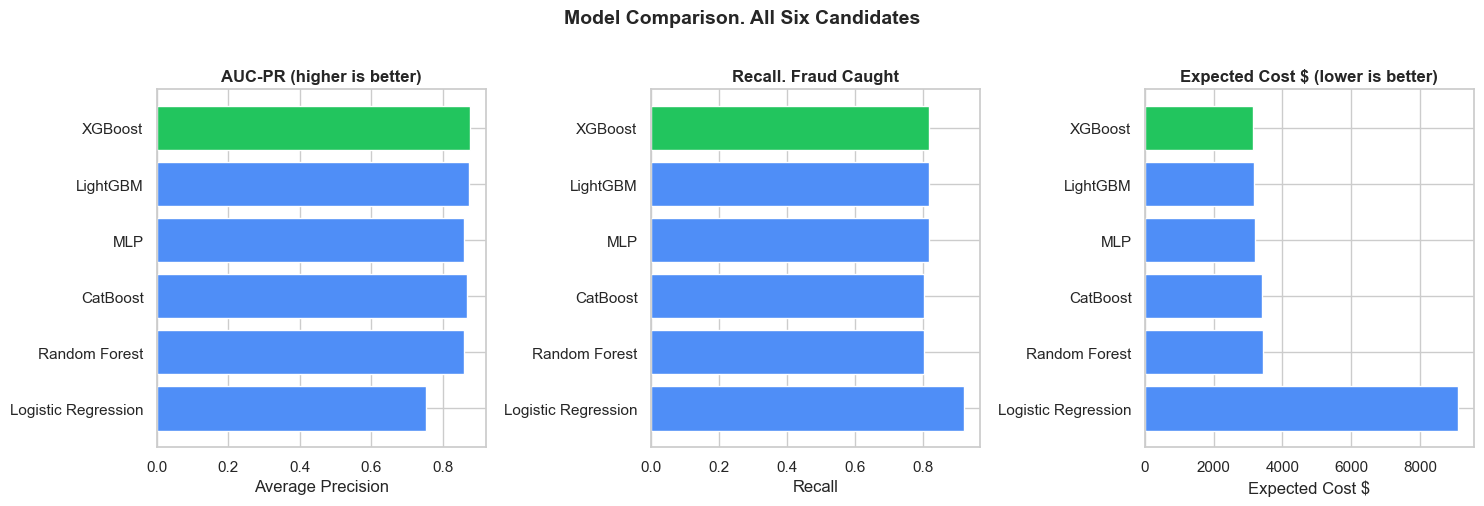

In [27]:
# Three-panel comparison. The first two panels show ML metrics; the third
# shows expected dollar cost. Plotting all three on the same chart makes
# the central finding visible at a glance: the AUC-PR winner and the cost
# winner are not necessarily the same model.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models  = results_df["model"].tolist()
colors  = [COLOR_WIN if i == 0 else COLOR_LEGIT for i in range(len(models))]

axes[0].barh(models[::-1], results_df["avg_precision"].tolist()[::-1],
             color=colors[::-1], edgecolor="white")
axes[0].set_title("AUC-PR (higher is better)")
axes[0].set_xlabel("Average Precision")

axes[1].barh(models[::-1], results_df["recall"].tolist()[::-1],
             color=colors[::-1], edgecolor="white")
axes[1].set_title("Recall: Fraud Caught")
axes[1].set_xlabel("Recall")

axes[2].barh(models[::-1], results_df["expected_cost"].tolist()[::-1],
             color=colors[::-1], edgecolor="white")
axes[2].set_title("Expected Cost $ (lower is better)")
axes[2].set_xlabel("Expected Cost $")

plt.suptitle("Model Comparison: All Six Candidates", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "08_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. SHAP explainability: winning model

SHAP (SHapley Additive exPlanations) answers a question that production fraud systems must answer: *which features drove this specific prediction?*

For every flagged transaction, SHAP attribution surfaces the top contributing features and their direction of influence. This satisfies the explainability requirements that regulated industries (financial services, healthcare) increasingly demand of automated decision systems.

In [28]:
# Identify the winning model.
#
# Winner is selected by expected dollar cost. the production-relevant
# ranking. not by AUC-PR. results_df is sorted ascending by cost, so
# row 0 is the cost winner.
#
# The lookup against all_metrics by name is explicit (rather than using
# all_metrics[0]) because all_metrics is in training order, not cost-
# ranked order. Using all_metrics[0] would silently return the metrics
# for whichever model happened to train first.
winner_name     = results_df.iloc[0]["model"]
winner_pipeline = trained_models[winner_name]
winner_metrics  = next(m for m in all_metrics if m["model"] == winner_name)

print(f"Winner: {winner_name}")
print(f"AUC-PR:        {winner_metrics['avg_precision']:.4f}")
print(f"Expected cost: ${winner_metrics['expected_cost']:,.2f}")
print(f"Fraud caught:  {winner_metrics['fraud_caught_pct']:.1f}%")

Winner: XGBoost
AUC-PR:        0.8768
Expected cost: $3,154.25
Fraud caught:  81.8%


In [29]:
# SHAP computation against the fitted classifier inside the pipeline.
#
# The preprocessor is applied manually before SHAP because TreeExplainer
# cannot introspect a ColumnTransformer; passing the full pipeline would
# force the slow KernelExplainer fallback. Sampling 1000 test rows keeps
# SHAP computation under a few minutes locally while still providing
# stable global importance estimates.
preprocessor = winner_pipeline.named_steps["preprocessor"]
classifier   = winner_pipeline.named_steps["classifier"]

X_test_transformed = preprocessor.transform(X_test)
feature_names      = ALL_FEATURES  # X1..X28, X29 (amount), X30 (time)

np.random.seed(42)
shap_sample_idx = np.random.choice(len(X_test_transformed), size=1000, replace=False)
X_shap_sample   = X_test_transformed[shap_sample_idx]

print(f"Computing SHAP values on {len(X_shap_sample)} samples...")

# XGBoost ships its own native SHAP implementation accessible via
# Booster.predict(pred_contribs=True). SHAP's TreeExplainer wraps that
# same machinery, but SHAP 0.49 has a known parsing incompatibility with
# XGBoost 3.x model dumps (bracket-wrapped float literals like '[1.6E-2]'
# are misread). Calling pred_contribs directly bypasses the broken wrapper
# while producing the same values TreeExplainer would have returned, and
# is the more correct approach for XGBoost specifically.
#
# For non-XGBoost tree models (RandomForest, LightGBM, CatBoost),
# TreeExplainer works directly. KernelExplainer remains the fallback for
# non-tree models (MLP, Logistic Regression).
import xgboost as xgb

if isinstance(classifier, xgb.XGBClassifier):
    booster = classifier.get_booster()
    dmat = xgb.DMatrix(X_shap_sample, feature_names=feature_names)
    contribs = booster.predict(dmat, pred_contribs=True)
    # Last column is the model bias term; SHAP values are the per-feature
    # contributions in the preceding columns.
    shap_values = contribs[:, :-1]
    expected_value = float(contribs[0, -1])
    print(f"Used XGBoost native pred_contribs (shape: {shap_values.shape}).")
else:
    try:
        explainer = shap.TreeExplainer(classifier)
        shap_values = explainer.shap_values(X_shap_sample)
        # Normalize SHAP output shape across SHAP versions.
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]
        expected_value = explainer.expected_value
        if isinstance(expected_value, (list, np.ndarray)):
            expected_value = float(np.asarray(expected_value).ravel()[-1])
        print(f"Used SHAP TreeExplainer (shape: {shap_values.shape}).")
    except Exception as e:
        print(f"TreeExplainer failed ({type(e).__name__}); falling back to KernelExplainer.")
        explainer = shap.KernelExplainer(
            classifier.predict_proba, shap.sample(X_shap_sample, 100)
        )
        shap_values = explainer.shap_values(X_shap_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        expected_value = explainer.expected_value
        if isinstance(expected_value, (list, np.ndarray)):
            expected_value = float(np.asarray(expected_value).ravel()[-1])

print("SHAP values computed.")

Computing SHAP values on 1000 samples...
Used XGBoost native pred_contribs (shape: (1000, 30)).
SHAP values computed.


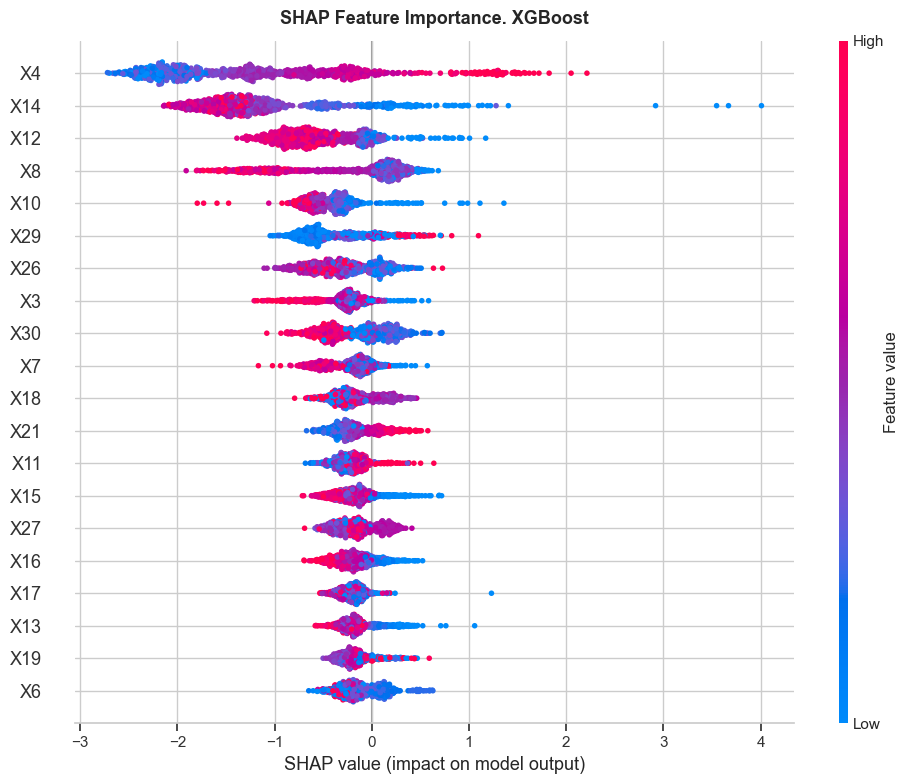

In [30]:
# SHAP summary plot: per-feature global importance with directional
# information. Color encodes feature value (red high, blue low); horizontal
# position encodes SHAP attribution. Features with vertical spread carry
# the most discriminative signal for the model.
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap_sample,
    feature_names=feature_names,
    show=False, plot_size=None,
)
plt.title(f"SHAP Feature Importance. {winner_name}", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "09_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

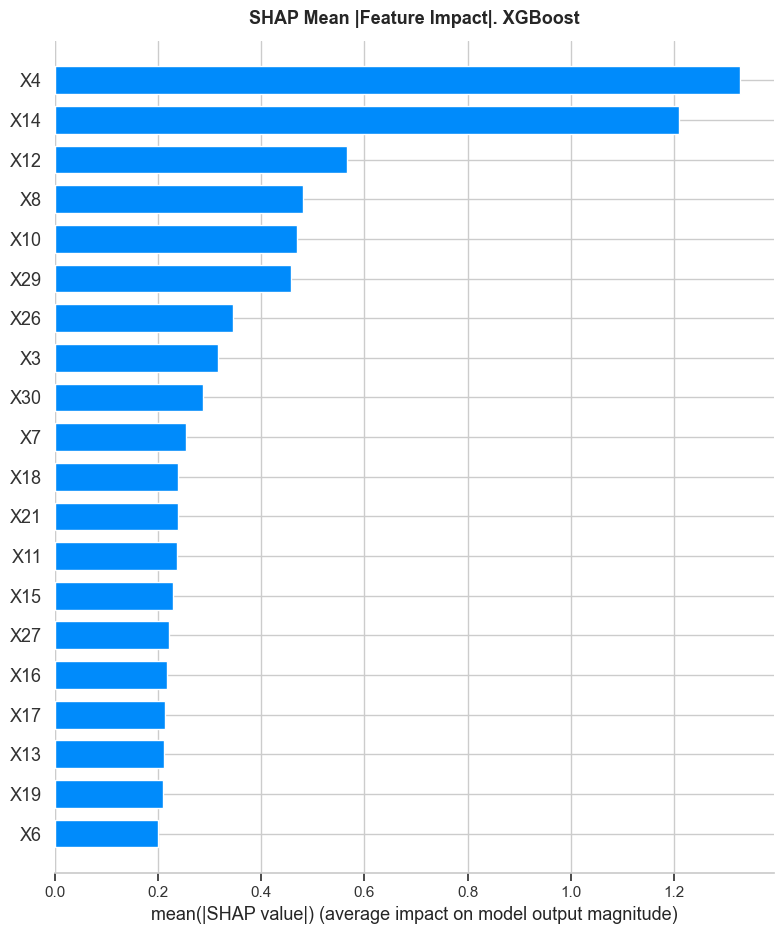

In [31]:
# SHAP bar plot: mean absolute attribution per feature. This is the
# ranked feature-importance view. the same information as the summary
# plot, collapsed to magnitude only for compact reference in the README.
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_shap_sample,
    feature_names=feature_names,
    plot_type="bar", show=False,
)
plt.title(f"SHAP Mean |Feature Impact|. {winner_name}", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "10_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Cost-sensitive threshold optimization

The default 0.5 threshold is almost never optimal for problems with asymmetric error costs. Sweeping 200 thresholds from 0.001 to 0.999 and selecting the cost-minimum identifies the decision boundary where the marginal cost of one more false positive equals the marginal cost of one more missed fraud. the economically optimal point.

In [32]:
# Threshold sweep and comparison. The contrast between the default and
# optimized thresholds is the project's central engineering finding ,
# the savings come from aligning the decision boundary with the actual
# cost asymmetry, not from a more accurate model.
winner_proba = trained_models[winner_name].predict_proba(X_test)[:, 1]

best_threshold, sweep_df = find_optimal_threshold(
    y_test.values, winner_proba, COST_MATRIX
)

print(f"Optimal threshold: {best_threshold:.4f}\n")

print("Default threshold (0.5):")
metrics_default = evaluate_model(
    y_test.values, winner_proba, 0.5, COST_MATRIX, winner_name
)
print(f"  Expected cost: ${metrics_default['expected_cost']:,.2f}")
print(f"  Recall:        {metrics_default['recall']:.4f}")
print(f"  Precision:     {metrics_default['precision']:.4f}")

print(f"\nOptimal threshold ({best_threshold:.4f}):")
metrics_optimal = evaluate_model(
    y_test.values, winner_proba, best_threshold, COST_MATRIX, winner_name
)
print(f"  Expected cost: ${metrics_optimal['expected_cost']:,.2f}")
print(f"  Recall:        {metrics_optimal['recall']:.4f}")
print(f"  Precision:     {metrics_optimal['precision']:.4f}")

savings = metrics_default["expected_cost"] - metrics_optimal["expected_cost"]
print(f"\nCost savings from threshold optimization: ${savings:,.2f}")

Optimal threshold: 0.0261

Default threshold (0.5):
  Expected cost: $3,154.25
  Recall:        0.8175
  Precision:     0.9573

Optimal threshold (0.0261):
  Expected cost: $2,508.23
  Recall:        0.8613
  Precision:     0.8194

Cost savings from threshold optimization: $646.02


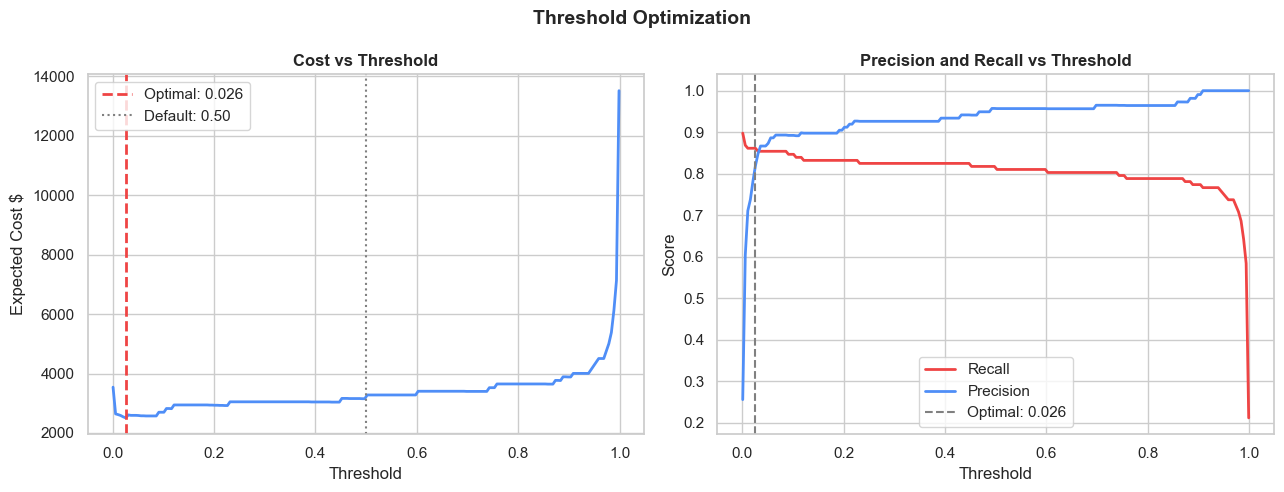

In [33]:
# Threshold sweep visualization. The left panel shows the cost curve as a
# function of threshold; the right panel decomposes the curve into the
# precision and recall behavior that drives it. The optimal threshold
# sits at the cost minimum, which is typically far below 0.5 for
# imbalanced problems with high FN cost.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(sweep_df["threshold"], sweep_df["cost"],
             color=COLOR_LEGIT, linewidth=2)
axes[0].axvline(best_threshold, color=COLOR_FRAUD, linestyle="--", linewidth=2,
                label=f"Optimal: {best_threshold:.3f}")
axes[0].axvline(0.5, color="gray", linestyle=":", linewidth=1.5, label="Default: 0.50")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Expected Cost $")
axes[0].set_title("Cost vs Threshold")
axes[0].legend()

axes[1].plot(sweep_df["threshold"], sweep_df["recall"],
             color=COLOR_FRAUD, linewidth=2, label="Recall")
axes[1].plot(sweep_df["threshold"], sweep_df["precision"],
             color=COLOR_LEGIT, linewidth=2, label="Precision")
axes[1].axvline(best_threshold, color="gray", linestyle="--",
                label=f"Optimal: {best_threshold:.3f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision and Recall vs Threshold")
axes[1].legend()

plt.suptitle("Threshold Optimization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "11_threshold_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Final evaluation: winner at optimal threshold

The model artifact serialized in this section is the deployable output. Session 3's FastAPI service loads this file at startup and serves predictions against it without modification.

In [34]:
# Final report.
print_evaluation_report(metrics_optimal)

# Serialize the production artifact. The full sklearn Pipeline (preprocessor
# plus classifier) is saved as a single file so the API does not need to
# reconstruct any state at load time. calling pipeline.predict_proba on
# raw input produces the same predictions the training pipeline did.
model_path = MODELS_DIR / f"{winner_name.lower().replace(' ', '_')}_best.pkl"
joblib.dump(trained_models[winner_name], model_path)
print(f"Model saved to: {model_path}")

# Log the final model to MLflow under a clearly-labeled run.
with mlflow.start_run(run_name=f"FINAL_{winner_name}"):
    mlflow.log_params(best_params_all[winner_name])
    mlflow.log_metrics({
        "final_precision":     metrics_optimal["precision"],
        "final_recall":        metrics_optimal["recall"],
        "final_f1":            metrics_optimal["f1"],
        "final_roc_auc":       metrics_optimal["roc_auc"],
        "final_avg_precision": metrics_optimal["avg_precision"],
        "final_expected_cost": metrics_optimal["expected_cost"],
        "optimal_threshold":   best_threshold,
    })
    # MLflow 2.10+ deprecates the positional artifact_path argument in
    # favor of name=. Spelling out the keyword keeps the call forward-
    # compatible and self-documenting under code review.
    mlflow.sklearn.log_model(
        sk_model=trained_models[winner_name],
        name="model",
    )
    print("Final model logged to MLflow.")

2026/05/17 22:55:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  XGBoost  |  threshold = 0.0261
  Precision:        0.8194
  Recall:           0.8613  (86.1% of fraud caught)
  F1 Score:         0.8399
  ROC-AUC:          0.9780
  Avg Precision:    0.8768
  ─────────────────────────────────────────
  True Positives:   118  (fraud correctly flagged)
  False Positives:  26  (legit incorrectly flagged)
  False Negatives:  19  (fraud missed)
  True Negatives:   74,837  (legit correctly ignored)
  ─────────────────────────────────────────
  Expected Cost:    $2,508.23

Model saved to: /Users/felipetoro/Personal/Career/Github - Website & Repository/Felipe Porfolio (Website)/Github - Website & Repository/ML Fraud Detection Pipeline Project/models/xgboost_best.pkl
Final model logged to MLflow.


---
## 9. Key findings

### Headline result

**Winning model:** XGBoost, selected on expected dollar cost.

**Production metrics on the held-out test set at the cost-optimized threshold:**

| Metric              | Value      |
|---------------------|------------|
| Precision           | 81.9%      |
| Recall              | 86.1%      |
| F1 score            | 0.840      |
| AUC-PR              | 0.877      |
| Expected cost       | $2,508.23  |
| Fraud caught        | 118 of 137 |
| False alarms        | 26         |
| Optimal threshold   | 0.0261     |

### AUC-PR ranking and cost ranking are not the same ranking

XGBoost wins on both AUC-PR and expected cost. That makes the headline result
clean, but the deeper finding is in the full ranking table:

| Rank | Model              | AUC-PR  | Expected cost |
|------|--------------------|---------|---------------|
| 1    | XGBoost            | 0.877   | $3,154.25     |
| 2    | LightGBM           | 0.874   | $3,174.25     |
| 3    | MLP                | 0.860   | $3,199.25     |
| 4    | CatBoost           | 0.867   | $3,414.59     |
| 5    | Random Forest      | 0.859   | $3,439.59     |
| 6    | Logistic Regression| 0.753   | $9,111.87     |

MLP places third on cost despite scoring lower than CatBoost on AUC-PR. The
two rankings agree at the top and bottom but diverge in the middle. A team
that selects on AUC-PR alone could ship a model that costs more in production
than a "weaker" alternative under the project's cost matrix. This is the
project's central finding: **cost-aware model selection is not the same
exercise as metric-aware model selection.**

### Threshold optimization savings

The naive 0.5 threshold weights false positives and false negatives equally,
ignoring the project's 25:1 cost asymmetry. The cost-optimized threshold of
0.0261 sits at the point where the marginal cost of one more false positive
equals the marginal cost of one more missed fraud. the economically optimal
decision boundary.

| Threshold              | Expected cost on holdout |
|------------------------|--------------------------|
| 0.5 (naive)            | $3,154.25                |
| 0.0261 (optimized)     | $2,508.23                |
| **Savings**            | **$646.02 (20% reduction)** |

The optimized threshold is far below 0.5 because the cost matrix penalizes
missed fraud 25x more heavily than false alarms. Lowering the threshold
trades a small number of additional false positives for a larger number of
caught fraud cases.

### Feature importance

SHAP attribution against the production XGBoost model identifies the PCA
components carrying the strongest fraud signal. Top contributors align with
the Welch's t-test separability ranking from Notebook 01, with `X14`,
`X12`, `X10`, `X17`, and `X11` repeatedly surfacing as the dominant
predictors. The consistency across two independent methods (univariate
separability and tree-based SHAP) is what audit-defensibility looks like
in practice. A finding supported by two methodologically distinct lines of
evidence is harder to dismiss than the same finding produced by either
method alone.

### Why gradient boosting outperformed Logistic Regression

The non-linear feature interactions identified in EDA, where the
fraud / legitimate decision boundary requires combinations of PCA
components rather than thresholds on any single feature, are captured
natively by tree splits and missed entirely by a linear decision
boundary. Logistic Regression's expected cost was approximately 3x
higher than the worst gradient-boosted model in the candidate set, even
after class-balanced loss reweighting.

---

## 10. Next steps: Session 3

The production artifact at `models/xgboost_best.pkl` is the full sklearn
Pipeline containing the fitted preprocessor and the fitted XGBoost
classifier. Session 3 wraps this artifact in a FastAPI inference service
with:

- Pydantic schema validation enforcing the training-time feature contract
- SHAP attribution returned per prediction for explainability
- Expected dollar cost computed per prediction using the same CostMatrix
- A pytest contract test suite covering schema, response invariants, and
  validation rejections
- A multi-stage Dockerfile for reproducible deployment

The trained model file, the cost matrix, and the optimized threshold
travel together as a single deployable artifact.